In [46]:
"""
Phase 4: Brand Exploration (30-mark Analysis Section)
=====================================================
Inputs : data/processed/{brand}_posts_clean.csv
         data/processed/{brand}_profiles_clean.csv
Outputs: outputs/figures/*.png   (figures referenced in the report)
         outputs/tables/*.csv    (tables referenced in the report)

Sections:
  1. Setup
  2. Descriptive engagement + temporal analysis
  3. Word frequency + TF-IDF distinctive vocabulary
  4. VADER sentiment analysis
  5. Topic modelling (gensim LDA)
  6. Word co-occurrence networks
  7. User interaction network (centrality + Louvain clustering)
  8. Perceptual map
"""
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Consistent visual style — matters for the 5-mark Presentation criterion
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Brand colour palette — used consistently across every figure
HF_COLOR  = "#FFD21E"   # Hugging Face yellow
REP_COLOR = "#E94B3C"   # Replicate red-orange
PALETTE   = {"Hugging Face": HF_COLOR, "Replicate": REP_COLOR}

# Project paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR  = PROJECT_ROOT / "outputs" / "figures"
TAB_DIR  = PROJECT_ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print(f"Reading cleaned data from : {PROC_DIR}")
print(f"Figures -> {FIG_DIR}")
print(f"Tables  -> {TAB_DIR}")

Reading cleaned data from : /Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Analytics-Specializations-and-Applications/BUSI4370_CW2/data/processed
Figures -> /Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Analytics-Specializations-and-Applications/BUSI4370_CW2/outputs/figures
Tables  -> /Users/shreyu/VSCODE/junk/UoN-Business-Analytics/Analytics-Specializations-and-Applications/BUSI4370_CW2/outputs/tables


In [47]:
hf_posts  = pd.read_csv(PROC_DIR / "huggingface_posts_clean.csv", parse_dates=["created_at"])
rep_posts = pd.read_csv(PROC_DIR / "replicate_posts_clean.csv", parse_dates=["created_at"])

hf_profiles  = pd.read_csv(PROC_DIR / "huggingface_profiles_clean.csv", parse_dates=["created_at"])
rep_profiles = pd.read_csv(PROC_DIR / "replicate_profiles_clean.csv", parse_dates=["created_at"])

# Tag each post with a human-readable brand label for grouped plots
hf_posts["brand_label"]  = "Hugging Face"
rep_posts["brand_label"] = "Replicate"

# Combined long-form frame for cross-brand plots
all_posts = pd.concat([hf_posts, rep_posts], ignore_index=True)

# Keep NaN-safe text columns (CSV round-trip can turn empty strings to NaN)
for col in ["text_raw", "text_clean", "text_clean_no_brand", "text_for_sentiment",
            "urls", "mentions", "hashtags", "domains"]:
    all_posts[col] = all_posts[col].fillna("")
    hf_posts[col]  = hf_posts[col].fillna("")
    rep_posts[col] = rep_posts[col].fillna("")

print(f"HF posts  : {len(hf_posts):>5}  ({hf_posts['author_did'].nunique()} unique authors)")
print(f"Rep posts : {len(rep_posts):>5}  ({rep_posts['author_did'].nunique()} unique authors)")
print(f"Combined  : {len(all_posts):>5}")

HF posts  :  1608  (770 unique authors)
Rep posts :   672  (437 unique authors)
Combined  :  2280


In [48]:
# --- FORCE datetime conversion (critical for resampling) ---
for df in [hf_posts, rep_posts]:
    df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True)

# Drop any rows where conversion failed
hf_posts = hf_posts.dropna(subset=["created_at"])
rep_posts = rep_posts.dropna(subset=["created_at"])

# Recreate combined dataframe AFTER cleaning
all_posts = pd.concat([hf_posts, rep_posts], ignore_index=True)

In [49]:
print(hf_posts["created_at"].dtype)
print(rep_posts["created_at"].dtype)

datetime64[ns, UTC]
datetime64[ns, UTC]


In [50]:
def headline_table(hf, rep) -> pd.DataFrame:
    """Top-line comparative metrics — referenced directly in Section 4 of the report."""
    rows = []
    for label, df in [("Hugging Face", hf), ("Replicate", rep)]:
        engaged_posts = (df["like_count"] + df["repost_count"] + df["reply_count"]) > 0
        rows.append({
            "Brand": label,
            "Posts": len(df),
            "Unique authors": df["author_did"].nunique(),
            "Posts/author": round(len(df) / max(df["author_did"].nunique(), 1), 2),
            "Mean likes": round(df["like_count"].mean(), 2),
            "Median likes": int(df["like_count"].median()),
            "Max likes": int(df["like_count"].max()),
            "Mean reposts": round(df["repost_count"].mean(), 2),
            "Mean replies received": round(df["reply_count"].mean(), 2),
            "Reply share (%)": round(df["is_reply"].mean() * 100, 1),
            "Engaged posts (%)": round(engaged_posts.mean() * 100, 1),
            "Posts with URLs (%)": round((df["n_urls"] > 0).mean() * 100, 1),
            "Posts with hashtags (%)": round((df["n_hashtags"] > 0).mean() * 100, 1),
            "Median tokens (clean)": int(df["word_count_clean"].median()),
        })
    return pd.DataFrame(rows).set_index("Brand").T

headline = headline_table(hf_posts, rep_posts)
headline.to_csv(TAB_DIR / "02_headline_metrics.csv")
print(headline)

Brand                    Hugging Face  Replicate
Posts                         1570.00     666.00
Unique authors                 742.00     432.00
Posts/author                     2.12       1.54
Mean likes                       4.65       2.90
Median likes                     1.00       1.00
Max likes                      510.00     113.00
Mean reposts                     0.75       0.39
Mean replies received            0.47       0.62
Reply share (%)                 29.40      45.30
Engaged posts (%)               63.90      81.50
Posts with URLs (%)             49.90      41.00
Posts with hashtags (%)         16.60       9.00
Median tokens (clean)           16.00      18.00


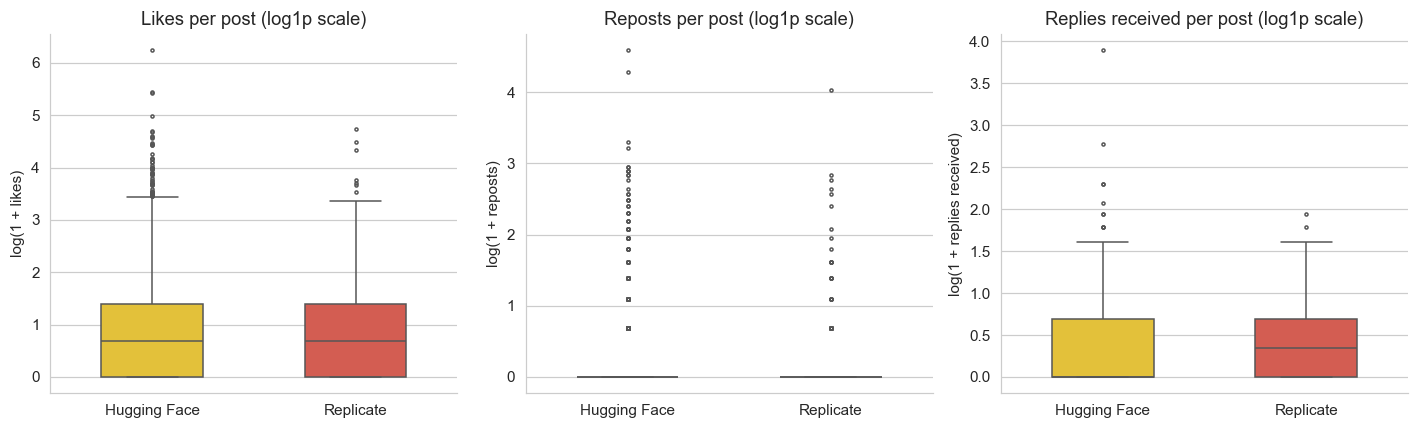

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = [("like_count", "Likes"), ("repost_count", "Reposts"), ("reply_count", "Replies received")]

for ax, (col, title) in zip(axes, metrics):
    data = all_posts[[col, "brand_label"]].copy()
    # log1p transform so we can see structure without zeros dominating the axis
    data[f"log_{col}"] = np.log1p(data[col])
    sns.boxplot(data=data, x="brand_label", y=f"log_{col}",
                hue="brand_label", palette=PALETTE, ax=ax,
                width=0.5, fliersize=2, legend=False)
    ax.set_title(f"{title} per post (log1p scale)")
    ax.set_xlabel("")
    ax.set_ylabel(f"log(1 + {title.lower()})")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_engagement_distributions.png", bbox_inches="tight")
plt.show()

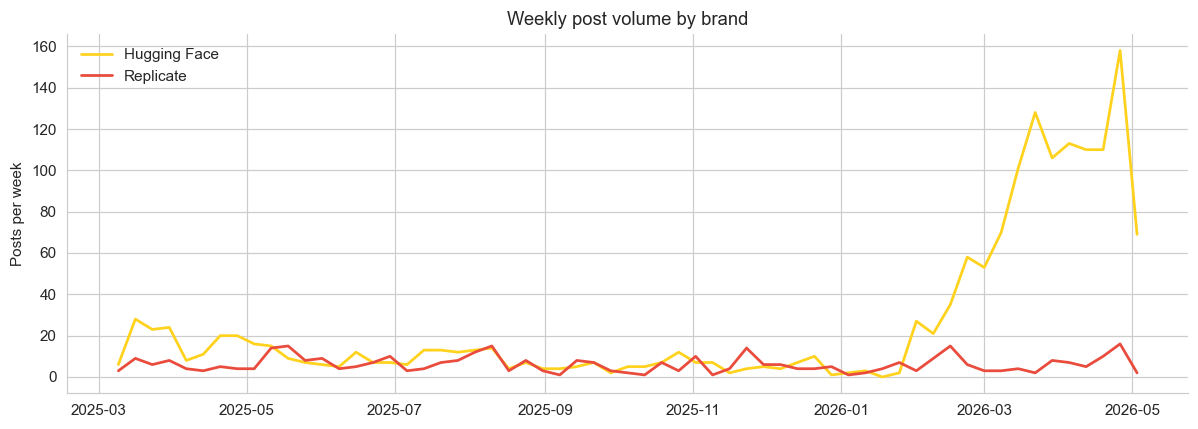

Date window used: 2025-03-07 -> 2026-04-29


In [52]:
def weekly_counts(df, label):
    df = df.sort_values("created_at")
    s = df.set_index("created_at").resample("W")["uri"].count()
    out = s.to_frame("posts").reset_index()
    out["brand_label"] = label
    return out

# Use a common date floor so both lines share a sensible x-axis
common_start = max(hf_posts["created_at"].min(), rep_posts["created_at"].min())
hf_window  = hf_posts[hf_posts["created_at"] >= common_start]
rep_window = rep_posts[rep_posts["created_at"] >= common_start]

weekly = pd.concat([weekly_counts(hf_window, "Hugging Face"),
                    weekly_counts(rep_window, "Replicate")])

fig, ax = plt.subplots(figsize=(11, 4))
for label, sub in weekly.groupby("brand_label"):
    ax.plot(sub["created_at"], sub["posts"], label=label,
            color=PALETTE[label], linewidth=1.8)
ax.set_title("Weekly post volume by brand")
ax.set_ylabel("Posts per week")
ax.set_xlabel("")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_posts_over_time.png", bbox_inches="tight")
plt.show()

print(f"Date window used: {common_start.date()} -> {max(hf_posts['created_at'].max(), rep_posts['created_at'].max()).date()}")

In [53]:
def top_engaged(df, n=5):
    df = df.copy()
    df["total_engagement"] = df["like_count"] + df["repost_count"] + df["reply_count"]
    cols = ["author_handle", "total_engagement", "like_count", "repost_count", "reply_count", "text_raw"]
    return df.nlargest(n, "total_engagement")[cols].reset_index(drop=True)

print("=== Top 5 most-engaged HF posts ===")
top_hf = top_engaged(hf_posts)
for i, row in top_hf.iterrows():
    print(f"\n[{i+1}] @{row['author_handle']}  (engagement={row['total_engagement']})")
    print(f"    likes={row['like_count']} reposts={row['repost_count']} replies={row['reply_count']}")
    print(f"    text: {row['text_raw'][:280]}")

print("\n\n=== Top 5 most-engaged Replicate posts ===")
top_rep = top_engaged(rep_posts)
for i, row in top_rep.iterrows():
    print(f"\n[{i+1}] @{row['author_handle']}  (engagement={row['total_engagement']})")
    print(f"    likes={row['like_count']} reposts={row['repost_count']} replies={row['reply_count']}")
    print(f"    text: {row['text_raw'][:280]}")

# Save for the report appendix or inline quoting
top_hf.to_csv(TAB_DIR / "03_top_engaged_huggingface.csv", index=False)
top_rep.to_csv(TAB_DIR / "03_top_engaged_replicate.csv", index=False)

=== Top 5 most-engaged HF posts ===

[1] @emollick.bsky.social  (engagement=629)
    likes=510 reposts=71 replies=48
    text: Want to talk to the past? Here' an LLM "trained entirely from scratch on a corpus of over 28,000 Victorian-era British texts published between 1837 & 1899, drawn from a dataset made available by the British Library"

Quite different from an LLM roleplaying a Victorian. huggingfac

[2] @ketanjoshi.co  (engagement=339)
    likes=227 reposts=97 replies=15
    text: Used @hf.co's new tool to multiply 2 five digit numbers

Chatbot: wrong answer, 0.3 watthours

Calc: right answer, 0.00000011 watthours (2.5 million times less energy)

New post - on how big tech is trying to recreate the plastics crisis in the world of software

www.linkedin.com

[3] @edzitron.com  (engagement=264)
    likes=231 reposts=24 replies=9
    text: lol they dropped deepseek v4 at 9pm on a Thursday - looks like a Pro model that’s competitive with Opus 4.6 and Gpt5.4 but at a much lower input 

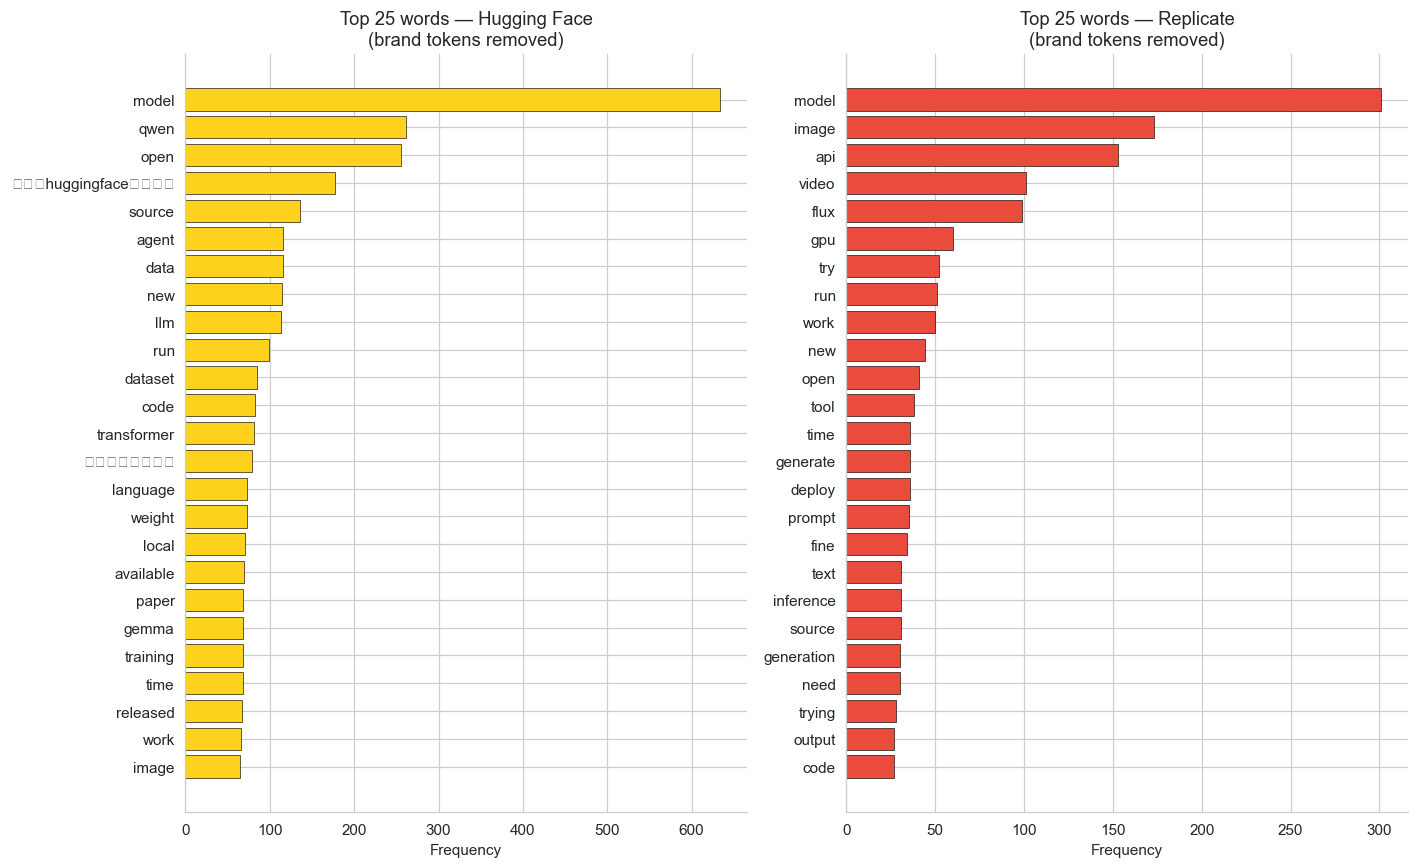

In [54]:
def top_words(series_of_clean_text, n=25):
    counts = Counter()
    for text in series_of_clean_text.dropna():
        counts.update(text.split())
    return pd.DataFrame(counts.most_common(n), columns=["word", "count"])

hf_top  = top_words(hf_posts["text_clean_no_brand"], n=25)
rep_top = top_words(rep_posts["text_clean_no_brand"], n=25)

# Side-by-side horizontal bar charts
fig, axes = plt.subplots(1, 2, figsize=(13, 8))
for ax, (label, df) in zip(axes, [("Hugging Face", hf_top), ("Replicate", rep_top)]):
    df = df.iloc[::-1]   # reverse so largest is at top
    ax.barh(df["word"], df["count"], color=PALETTE[label], edgecolor="black", linewidth=0.4)
    ax.set_title(f"Top 25 words — {label}\n(brand tokens removed)")
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.savefig(FIG_DIR / "04_top_words_comparison.png", bbox_inches="tight")
plt.show()

hf_top.to_csv(TAB_DIR / "04_top_words_huggingface.csv", index=False)
rep_top.to_csv(TAB_DIR / "04_top_words_replicate.csv", index=False)

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Build a 2-document corpus where each "document" is all of one brand's posts concatenated.
# TF-IDF then surfaces words that are characteristic of one brand vs the other.
hf_corpus  = " ".join(hf_posts["text_clean_no_brand"].tolist())
rep_corpus = " ".join(rep_posts["text_clean_no_brand"].tolist())

vec = TfidfVectorizer(max_features=5000, min_df=1, ngram_range=(1, 2))
tfidf = vec.fit_transform([hf_corpus, rep_corpus])
vocab = vec.get_feature_names_out()

tfidf_df = pd.DataFrame(tfidf.toarray(), index=["Hugging Face", "Replicate"], columns=vocab).T

# Words distinctive to HF: high HF score, low/zero Replicate score, and vice versa.
# We use a simple ratio with smoothing to handle zero counts.
tfidf_df["hf_distinctiveness"]  = tfidf_df["Hugging Face"] / (tfidf_df["Replicate"] + 1e-3)
tfidf_df["rep_distinctiveness"] = tfidf_df["Replicate"]   / (tfidf_df["Hugging Face"] + 1e-3)

# Filter: must appear in both brands at a non-trivial level OR be unique enough to one
top_hf_distinct  = tfidf_df.nlargest(25, "hf_distinctiveness")[["Hugging Face", "Replicate", "hf_distinctiveness"]]
top_rep_distinct = tfidf_df.nlargest(25, "rep_distinctiveness")[["Hugging Face", "Replicate", "rep_distinctiveness"]]

print("=== Most distinctively HUGGING FACE terms (high TF-IDF for HF, low for Replicate) ===")
print(top_hf_distinct.head(20))
print("\n=== Most distinctively REPLICATE terms ===")
print(top_rep_distinct.head(20))

top_hf_distinct.head(20).to_csv(TAB_DIR / "05_distinctive_terms_huggingface.csv")
top_rep_distinct.head(20).to_csv(TAB_DIR / "05_distinctive_terms_replicate.csv")

=== Most distinctively HUGGING FACE terms (high TF-IDF for HF, low for Replicate) ===
                         Hugging Face  Replicate  hf_distinctiveness
transformer                  0.107878   0.000000          107.878363
このリポジトリは                     0.105215   0.000000          105.214700
apache                       0.066592   0.000000           66.591582
datasets                     0.063928   0.000000           63.927919
今日のhuggingfaceトレンド           0.167727   0.001935           57.148739
multimodal                   0.055937   0.000000           55.936929
unsloth                      0.042619   0.000000           42.618613
nemotron                     0.039955   0.000000           39.954949
に関するものです                     0.038623   0.000000           38.623118
今日のhuggingfaceトレンド qwen      0.038623   0.000000           38.623118
tt                           0.035959   0.000000           35.959454
moe                          0.034628   0.000000           34.627623
robotics         

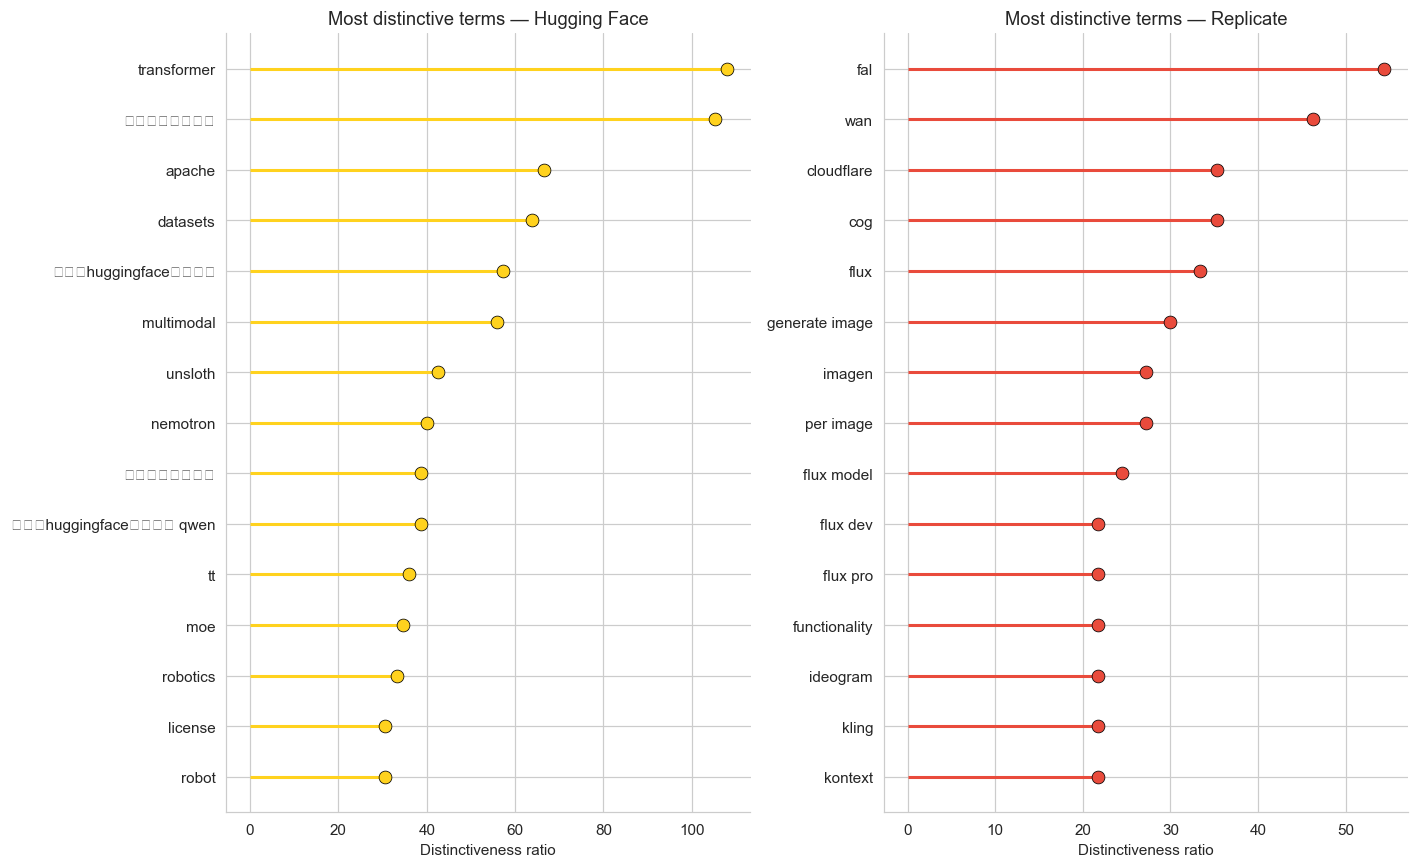

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 8))
for ax, (label, df, color) in zip(
    axes,
    [("Hugging Face", top_hf_distinct.head(15), HF_COLOR),
     ("Replicate",    top_rep_distinct.head(15), REP_COLOR)]
):
    df = df.iloc[::-1]   # largest at top
    score_col = "hf_distinctiveness" if label == "Hugging Face" else "rep_distinctiveness"
    ax.hlines(df.index, 0, df[score_col], color=color, linewidth=2)
    ax.scatter(df[score_col], df.index, color=color, s=70, edgecolor="black", linewidth=0.5, zorder=3)
    ax.set_title(f"Most distinctive terms — {label}")
    ax.set_xlabel("Distinctiveness ratio")

plt.tight_layout()
plt.savefig(FIG_DIR / "05_distinctive_terms.png", bbox_inches="tight")
plt.show()

In [57]:
def top_items(series_of_semicolon_strings, n=15):
    counts = Counter()
    for s in series_of_semicolon_strings.dropna():
        if s:
            counts.update(s.split(";"))
    counts.pop("", None)
    return pd.DataFrame(counts.most_common(n), columns=["item", "count"])

print("=== Top hashtags ===")
hf_hash  = top_items(hf_posts["hashtags"])
rep_hash = top_items(rep_posts["hashtags"])
print("HF       :", list(zip(hf_hash["item"].head(8), hf_hash["count"].head(8))))
print("Replicate:", list(zip(rep_hash["item"].head(8), rep_hash["count"].head(8))))

print("\n=== Top domains ===")
# Filter out the brand's own domain (we expect it to dominate by construction)
def filter_self_domain(df, exclude):
    return df[~df["item"].str.contains("|".join(exclude), case=False, na=False)]

hf_dom  = filter_self_domain(top_items(hf_posts["domains"], n=30), ["huggingface", "hf.co"]).head(15)
rep_dom = filter_self_domain(top_items(rep_posts["domains"], n=30), ["replicate", "r8.im"]).head(15)
print("HF (excluding huggingface.co):", list(zip(hf_dom["item"].head(8), hf_dom["count"].head(8))))
print("Replicate (excluding replicate.com):", list(zip(rep_dom["item"].head(8), rep_dom["count"].head(8))))

hf_hash.to_csv(TAB_DIR  / "06_top_hashtags_huggingface.csv", index=False)
rep_hash.to_csv(TAB_DIR / "06_top_hashtags_replicate.csv", index=False)
hf_dom.to_csv(TAB_DIR   / "07_top_domains_huggingface.csv", index=False)
rep_dom.to_csv(TAB_DIR  / "07_top_domains_replicate.csv", index=False)

=== Top hashtags ===
HF       : [('#ai', 110), ('#huggingface', 66), ('#llm', 35), ('#opensource', 27), ('#machinelearning', 25), ('#agentwyre', 20), ('#1', 11), ('#hackernews', 9)]
Replicate: [('#ai', 10), ('#x', 5), ('#buildinpublic', 4), ('#flux', 4), ('#replicate', 3), ('#machinelearning', 3), ('#news', 3), ('#ml', 2)]

=== Top domains ===
HF (excluding huggingface.co): [('github.com', 93), ('arxiv.org', 41), ('llama.cpp', 29), ('ggml.ai', 17), ('qwen3.5は', 16), ('qwen3.5', 16), ('transformers.js', 10), ('qwen3.6', 9)]
Replicate (excluding replicate.com): [('github.com', 15), ('fal.ai', 11), ('x.com', 10), ('flux.1', 8), ('huggingface.co', 6), ('arxiv.org', 6), ('youtu.be', 5), ('flux.2', 4)]
